In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rodrigotertulino/student-performance-for-recommender-systems/interactions_real_rich_scaled_processed.csv


# **"Federated Learning for Student Performance Prediction"**

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
import random
import copy
from collections import defaultdict

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## **1. Load Data**

In [3]:
try:
    df = pd.read_csv('/kaggle/input/datasets/rodrigotertulino/student-performance-for-recommender-systems/interactions_real_rich_scaled_processed.csv')
except:
    df = pd.read_csv('interactions_real_rich_scaled_processed.csv')

print(f"Dataset: {df.shape[0]} samples, {df['user_id_new'].nunique()} students")

Dataset: 32499 samples, 1365 students


## **2. Create Clients (Each student = one client)**

In [4]:
student_ids = df['user_id_new'].unique()
client_data = {}
for sid in student_ids:
    client_data[sid] = df[df['user_id_new'] == sid].copy()

# Filter clients with at least 5 samples
client_data = {k: v for k, v in client_data.items() if len(v) >= 5}
print(f"Clients: {len(client_data)} (min 5 samples)")

Clients: 1310 (min 5 samples)


## **3. Model Architecture**

In [5]:
class StudentPerformanceModel(nn.Module):
    
    def __init__(self, input_dim=3, hidden_dims=[256, 128, 64, 32]):
        super(StudentPerformanceModel, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # Handle batch_size=1 for BatchNorm
        if x.shape[0] == 1:
            self.network.eval()
            out = self.network(x)
            self.network.train()
            return out
        return self.network(x)
    
    def get_weights(self):
        return {k: v.cpu().clone() for k, v in self.state_dict().items()}
    
    def set_weights(self, weights):
        current_device = next(self.parameters()).device
        for k, v in weights.items():
            weights[k] = v.to(current_device)
        self.load_state_dict(weights)

## **4. FedCA Aggregator**

In [6]:
class FedCAAggregator:
    """Composite aggregation: similarity + complementarity + size"""
    
    def __init__(self, alpha=0.33, beta=0.33, gamma=0.34):
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
    
    def compute_similarity_weights(self, client_models, client_stats):
        n = len(client_models)
        if n <= 1:
            return np.ones(max(1, n)) / max(1, n)
        
        # Convert models to vectors
        vectors = []
        for model in client_models:
            params = []
            for key in sorted(model.keys()):
                if 'weight' in key and model[key].dtype == torch.float32:
                    params.append(model[key].numpy().flatten())
            if params:
                vec = np.concatenate(params)
                vectors.append(vec / (np.linalg.norm(vec) + 1e-8))
            else:
                vectors.append(np.array([1.0]))
        
        # Cosine similarity matrix
        sim = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                sim[i, j] = max(0, np.dot(vectors[i], vectors[j]))
        
        weights = sim.mean(axis=1)
        return weights / (weights.sum() + 1e-8)
    
    def compute_complementarity_weights(self, client_stats):
        n = len(client_stats)
        if n <= 1:
            return np.ones(max(1, n)) / max(1, n)
        
        user_means = np.array([s.get('user_mean_correct', 0.5) for s in client_stats])
        skill_means = np.array([s.get('skill_mean_correct', 0.5) for s in client_stats])
        
        complementarity = (np.abs(user_means - user_means.mean()) + 
                          np.abs(skill_means - skill_means.mean())) / 2.0
        
        if complementarity.sum() > 0:
            return complementarity / (complementarity.sum() + 1e-8)
        return np.ones(n) / n
    
    def compute_size_weights(self, client_sizes):
        sizes = np.array(client_sizes, dtype=np.float32)
        return sizes / (sizes.sum() + 1e-8)
    
    def aggregate(self, client_updates, client_stats):
        n = len(client_updates)
        if n == 0:
            return {}, {}
        
        models = [up['weights'] for up in client_updates]
        sizes = [up['size'] for up in client_updates]
        
        sim_w = self.compute_similarity_weights(models, client_stats)
        comp_w = self.compute_complementarity_weights(client_stats)
        size_w = self.compute_size_weights(sizes)
        
        final_w = (self.alpha * sim_w + self.beta * comp_w + self.gamma * size_w)
        final_w = final_w / (final_w.sum() + 1e-8)
        
        aggregated = {}
        for key in models[0].keys():
            if models[0][key].dtype == torch.float32:
                weighted = torch.zeros_like(models[0][key])
                for i, model in enumerate(models):
                    weighted += torch.tensor(final_w[i], dtype=torch.float32) * model[key]
                aggregated[key] = weighted
            else:
                aggregated[key] = models[0][key].clone()
        
        return aggregated, {'weights': final_w.tolist()}

## **5. Federated Client**

In [7]:
class FederatedClient:
    def __init__(self, client_id, data, model, device='cpu'):
        self.client_id = client_id
        self.device = device
        self.model = copy.deepcopy(model).to(device)
        self.criterion = nn.MSELoss()
        
        # Prepare data
        features = ['user_mean_correct', 'skill_mean_correct', 'user_interaction_count']
        X = data[features].values.astype(np.float32)
        y = data['target_correct_rate'].values.astype(np.float32)
        
        self.scaler = StandardScaler()
        X = self.scaler.fit_transform(X)
        self.X, self.y = torch.tensor(X), torch.tensor(y).reshape(-1, 1)
        
        # Client statistics
        self.stats = {
            'user_mean_correct': float(data['user_mean_correct'].mean()),
            'skill_mean_correct': float(data['skill_mean_correct'].mean()),
            'n_samples': len(data),
            'target_mean': float(data['target_correct_rate'].mean())
        }
    
    def local_train(self, epochs=10, batch_size=32, lr=0.001):
        self.model.train()
        X, y = self.X.to(self.device), self.y.to(self.device)
        
        dataset = TensorDataset(X, y)
        batch = min(batch_size, max(2, len(dataset)))
        loader = DataLoader(dataset, batch_size=batch, shuffle=True)
        
        optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        losses = []
        for _ in range(epochs):
            epoch_loss = 0
            for bx, by in loader:
                optimizer.zero_grad()
                loss = self.criterion(self.model(bx), by)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
            losses.append(epoch_loss / len(loader))
            scheduler.step()
        
        return {
            'client_id': self.client_id,
            'weights': self.model.get_weights(),
            'size': len(self.X),
            'stats': self.stats,
            'losses': losses
        }
    
    def evaluate(self):
        self.model.eval()
        with torch.no_grad():
            pred = self.model(self.X.to(self.device)).cpu().numpy().flatten()
            true = self.y.numpy().flatten()
            return {
                'mse': mean_squared_error(true, pred),
                'rmse': np.sqrt(mean_squared_error(true, pred)),
                'mae': mean_absolute_error(true, pred),
                'r2': r2_score(true, pred),
                'predictions': pred,
                'true_values': true
            }
    
    def set_model(self, model):
        weights = model.get_weights()
        for k, v in weights.items():
            weights[k] = v.to(self.device)
        self.model.load_state_dict(weights)

## **6. Federated Server**

In [8]:
class FederatedServer:
    def __init__(self, global_model, aggregator, device='cpu'):
        self.global_model = global_model.to(device)
        self.aggregator = aggregator
        self.device = device
        self.history = defaultdict(list)
    
    def federated_round(self, clients, epochs=10):
        if not clients:
            return [], {}
        
        for client in clients:
            client.set_model(self.global_model)
        
        updates = []
        stats = []
        for client in clients:
            up = client.local_train(epochs=epochs)
            updates.append(up)
            stats.append(up['stats'])
        
        agg_weights, _ = self.aggregator.aggregate(updates, stats)
        if agg_weights:
            self.global_model.set_weights(agg_weights)
        
        avg_loss = np.mean([u['losses'][-1] for u in updates]) if updates else 0
        self.history['loss'].append(avg_loss)
        return updates

## **7. Training**

In [9]:
# Select 100 clients with most data
sorted_clients = sorted(client_data.items(), key=lambda x: len(x[1]), reverse=True)[:100]
clients = []
for cid, data in sorted_clients:
    if len(data) >= 10:
        clients.append(FederatedClient(cid, data, StudentPerformanceModel(), device))

print(f"Training clients: {len(clients)}")

# Initialize
global_model = StudentPerformanceModel()
aggregator = FedCAAggregator(alpha=0.33, beta=0.33, gamma=0.34)
server = FederatedServer(global_model, aggregator, device)

# Training loop
print("\nTraining Federated Learning...")
for round_num in range(1, 31):
    selected = random.sample(clients, min(20, len(clients)))
    server.federated_round(selected, epochs=10)
    
    if round_num % 10 == 0:
        print(f"Round {round_num:2d}/30 - Loss: {server.history['loss'][-1]:.6f}")

Training clients: 100

Training Federated Learning...
Round 10/30 - Loss: 0.032722
Round 20/30 - Loss: 0.038133
Round 30/30 - Loss: 0.034151


## **8. Evaluation**

In [10]:
print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)

metrics = [c.evaluate() for c in clients]

avg_mse = np.mean([m['mse'] for m in metrics])
avg_rmse = np.mean([m['rmse'] for m in metrics])
avg_mae = np.mean([m['mae'] for m in metrics])
avg_r2 = np.mean([m['r2'] for m in metrics])

print(f"MSE:  {avg_mse:.6f}")
print(f"RMSE: {avg_rmse:.4f}")
print(f"MAE:  {avg_mae:.4f}")
print(f"R²:   {avg_r2:.4f}")
print("="*50)


EVALUATION RESULTS
MSE:  0.033421
RMSE: 0.1791
MAE:  0.1396
R²:   0.2121


## **9. Visualization**

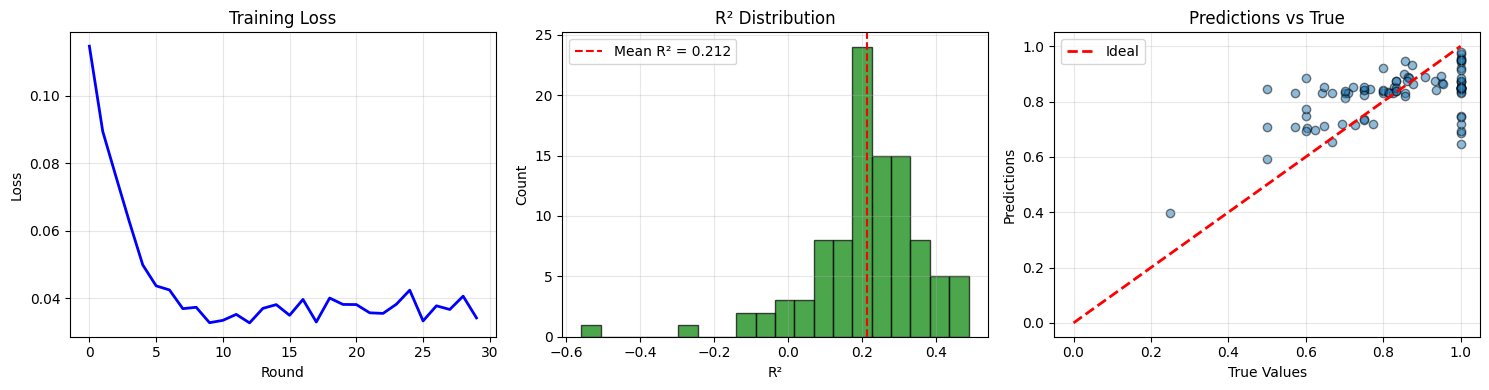

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(server.history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# R² distribution
r2_scores = [m['r2'] for m in metrics]
axes[1].hist(r2_scores, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(avg_r2, color='red', linestyle='--', label=f'Mean R² = {avg_r2:.3f}')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Count')
axes[1].set_title('R² Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Predictions vs True values
sample = metrics[0]
axes[2].scatter(sample['true_values'], sample['predictions'], alpha=0.5, edgecolors='black')
axes[2].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal')
axes[2].set_xlabel('True Values')
axes[2].set_ylabel('Predictions')
axes[2].set_title('Predictions vs True')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **10. Save Results**

In [12]:
torch.save(global_model.state_dict(), '/kaggle/working/federated_model.pth')
pd.DataFrame(metrics).to_csv('/kaggle/working/federated_results.csv', index=False)

print("\n✅ Model saved to: /kaggle/working/federated_model.pth")
print("✅ Results saved to: /kaggle/working/federated_results.csv")


✅ Model saved to: /kaggle/working/federated_model.pth
✅ Results saved to: /kaggle/working/federated_results.csv


## **11. Case Study**

In [13]:
# Find client with R² closest to average
typical_idx = np.argmin([abs(m['r2'] - avg_r2) for m in metrics])
typical_client = clients[typical_idx]
typical_results = metrics[typical_idx]

print(f"\n{'='*50}")
print(f"CASE STUDY - Student {typical_client.client_id}")
print(f"{'='*50}")
print(f"Profile:")
print(f"  • Performance: {typical_client.stats['user_mean_correct']:.3f}")
print(f"  • Interactions: {typical_client.stats['n_samples']}")
print(f"\nPerformance:")
print(f"  • R²:  {typical_results['r2']:.4f}")
print(f"  • MAE: {typical_results['mae']:.4f}")

# Get skill data from the original dataframe
skill_data = df[df['user_id_new'] == typical_client.client_id][['skill_id_new', 'skill_mean_correct']].copy()
skill_data = skill_data.drop_duplicates(subset=['skill_id_new'])
skill_data['predicted'] = typical_results['predictions'][:len(skill_data)]

print(f"\nTop 5 Recommended Skills:")
for _, row in skill_data.nlargest(5, 'predicted').iterrows():
    print(f"  • Skill {int(row['skill_id_new'])}: {row['predicted']:.3f} (difficulty: {row['skill_mean_correct']:.3f})")

print(f"\nBottom 5 Skills (Need Improvement):")
for _, row in skill_data.nsmallest(5, 'predicted').iterrows():
    print(f"  • Skill {int(row['skill_id_new'])}: {row['predicted']:.3f} (difficulty: {row['skill_mean_correct']:.3f})")
    
print("="*50)


CASE STUDY - Student 435
Profile:
  • Performance: 0.697
  • Interactions: 74

Performance:
  • R²:  0.2123
  • MAE: 0.1111

Top 5 Recommended Skills:
  • Skill 10: 0.992 (difficulty: 0.965)
  • Skill 7: 0.977 (difficulty: 0.899)
  • Skill 93: 0.977 (difficulty: 0.898)
  • Skill 77: 0.974 (difficulty: 0.890)
  • Skill 80: 0.970 (difficulty: 0.881)

Bottom 5 Skills (Need Improvement):
  • Skill 89: 0.527 (difficulty: 0.213)
  • Skill 31: 0.546 (difficulty: 0.291)
  • Skill 65: 0.599 (difficulty: 0.382)
  • Skill 34: 0.601 (difficulty: 0.385)
  • Skill 84: 0.618 (difficulty: 0.405)
